In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report,confusion_matrix)
from sklearn.model_selection import GridSearchCV


In [93]:
df = pd.read_csv("/content/Internship_Selection_Dataset.csv")

In [94]:
df.head()

,student_id,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,extracurricular,...,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,placement_training,selected
0,1,6.87,7,0,0,4,3,2,7,Yes,...,0,7,5,9,3,1,4,4,Yes,1
1,2,9.75,4,4,2,3,3,6,1,Yes,...,3,2,8,8,3,9,8,5,Yes,1
2,3,8.66,2,1,1,2,1,4,6,Yes,...,4,1,5,2,2,1,3,2,Yes,1
3,4,7.99,5,4,2,8,8,10,8,No,...,1,5,5,9,2,7,10,1,Yes,1
4,5,5.78,3,2,2,4,9,1,7,Yes,...,4,7,3,8,7,8,6,5,Yes,1


In [95]:
df.tail()

,student_id,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,extracurricular,...,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,placement_training,selected
9995,9996,9.29,8,3,1,10,2,4,6,No,...,4,5,10,2,6,5,3,4,No,0
9996,9997,9.49,4,2,1,7,1,3,5,Yes,...,2,8,6,10,1,5,1,1,Yes,0
9997,9998,9.73,8,0,0,1,4,4,9,Yes,...,3,6,4,5,9,10,2,3,No,1
9998,9999,6.99,5,1,1,3,6,9,5,No,...,2,2,10,2,4,8,1,4,No,1
9999,10000,6.09,3,3,0,5,6,4,6,Yes,...,4,9,1,1,5,7,8,3,No,1


In [96]:
df.shape

(10000, 21)

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               10000 non-null  int64  
 1   CGPA                     10000 non-null  float64
 2   skills_score             10000 non-null  int64  
 3   projects_count           10000 non-null  int64  
 4   internships_done         10000 non-null  int64  
 5   communication_score      10000 non-null  int64  
 6   aptitude_score           10000 non-null  int64  
 7   coding_test_score        10000 non-null  int64  
 8   resume_score             10000 non-null  int64  
 9   extracurricular          10000 non-null  object 
 10  college_tier             10000 non-null  object 
 11  hackathons_participated  10000 non-null  int64  
 12  certifications_count     10000 non-null  int64  
 13  linkedin_activity_score  10000 non-null  int64  
 14  github_score           

In [98]:
df.describe()

,student_id,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,selected
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.0000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,5000.50000,7.470792,5.480200,2.534300,1.502000,5.562800,5.526600,5.44940,5.572200,2.520500,4.474100,5.5000,5.49650,5.480200,5.469400,5.49130,2.502100,0.737400
std,2886.89568,1.438135,2.884829,1.690713,1.115043,2.864765,2.861627,2.86532,2.875868,1.699079,2.871124,2.8876,2.88094,2.881708,2.864557,2.88145,1.711341,0.440069
min,1.00000,5.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.00000,1.000000,0.000000,0.000000,1.0000,1.00000,1.000000,1.000000,1.00000,0.000000,0.000000
25%,2500.75000,6.230000,3.000000,1.000000,1.000000,3.000000,3.000000,3.00000,3.000000,1.000000,2.000000,3.0000,3.00000,3.000000,3.000000,3.00000,1.000000,0.000000
50%,5000.50000,7.460000,5.000000,3.000000,2.000000,6.000000,6.000000,5.00000,6.000000,3.000000,4.000000,6.0000,6.00000,5.000000,5.000000,5.00000,3.000000,1.000000
75%,7500.25000,8.700000,8.000000,4.000000,2.000000,8.000000,8.000000,8.00000,8.000000,4.000000,7.000000,8.0000,8.00000,8.000000,8.000000,8.00000,4.000000,1.000000
max,10000.00000,10.000000,10.000000,5.000000,3.000000,10.000000,10.000000,10.00000,10.000000,5.000000,9.000000,10.0000,10.00000,10.000000,10.000000,10.00000,5.000000,1.000000


In [99]:
df.isnull().sum()

,0
student_id,0
CGPA,0
skills_score,0
projects_count,0
internships_done,0
communication_score,0
aptitude_score,0
coding_test_score,0
resume_score,0
extracurricular,0


In [100]:
df.duplicated().sum()

np.int64(0)

In [101]:
df.drop_duplicates(inplace=True)

In [102]:

num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include='object').columns

print(num_cols)
print(cat_cols)

Index(['student_id', 'CGPA', 'skills_score', 'projects_count',
       'internships_done', 'communication_score', 'aptitude_score',
       'coding_test_score', 'resume_score', 'hackathons_participated',
       'certifications_count', 'linkedin_activity_score', 'github_score',
       'soft_skills_score', 'interview_score', 'consistency_score', 'backlogs',
       'selected'],
      dtype='object')
Index(['extracurricular', 'college_tier', 'placement_training'], dtype='object')


In [103]:
for col in df.select_dtypes(include='object'):
    print(col)
    print(df[col].value_counts())
    print("-"*30)

extracurricular
extracurricular
Yes    6025
No     3975
Name: count, dtype: int64
------------------------------
college_tier
college_tier
Tier 2    4944
Tier 1    3044
Tier 3    2012
Name: count, dtype: int64
------------------------------
placement_training
placement_training
Yes    6876
No     3124
Name: count, dtype: int64
------------------------------


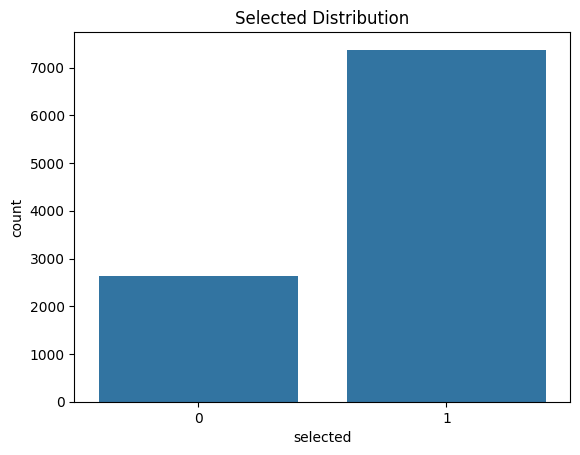

In [104]:
sns.countplot(x='selected', data=df)
plt.title("Selected Distribution")
plt.show()

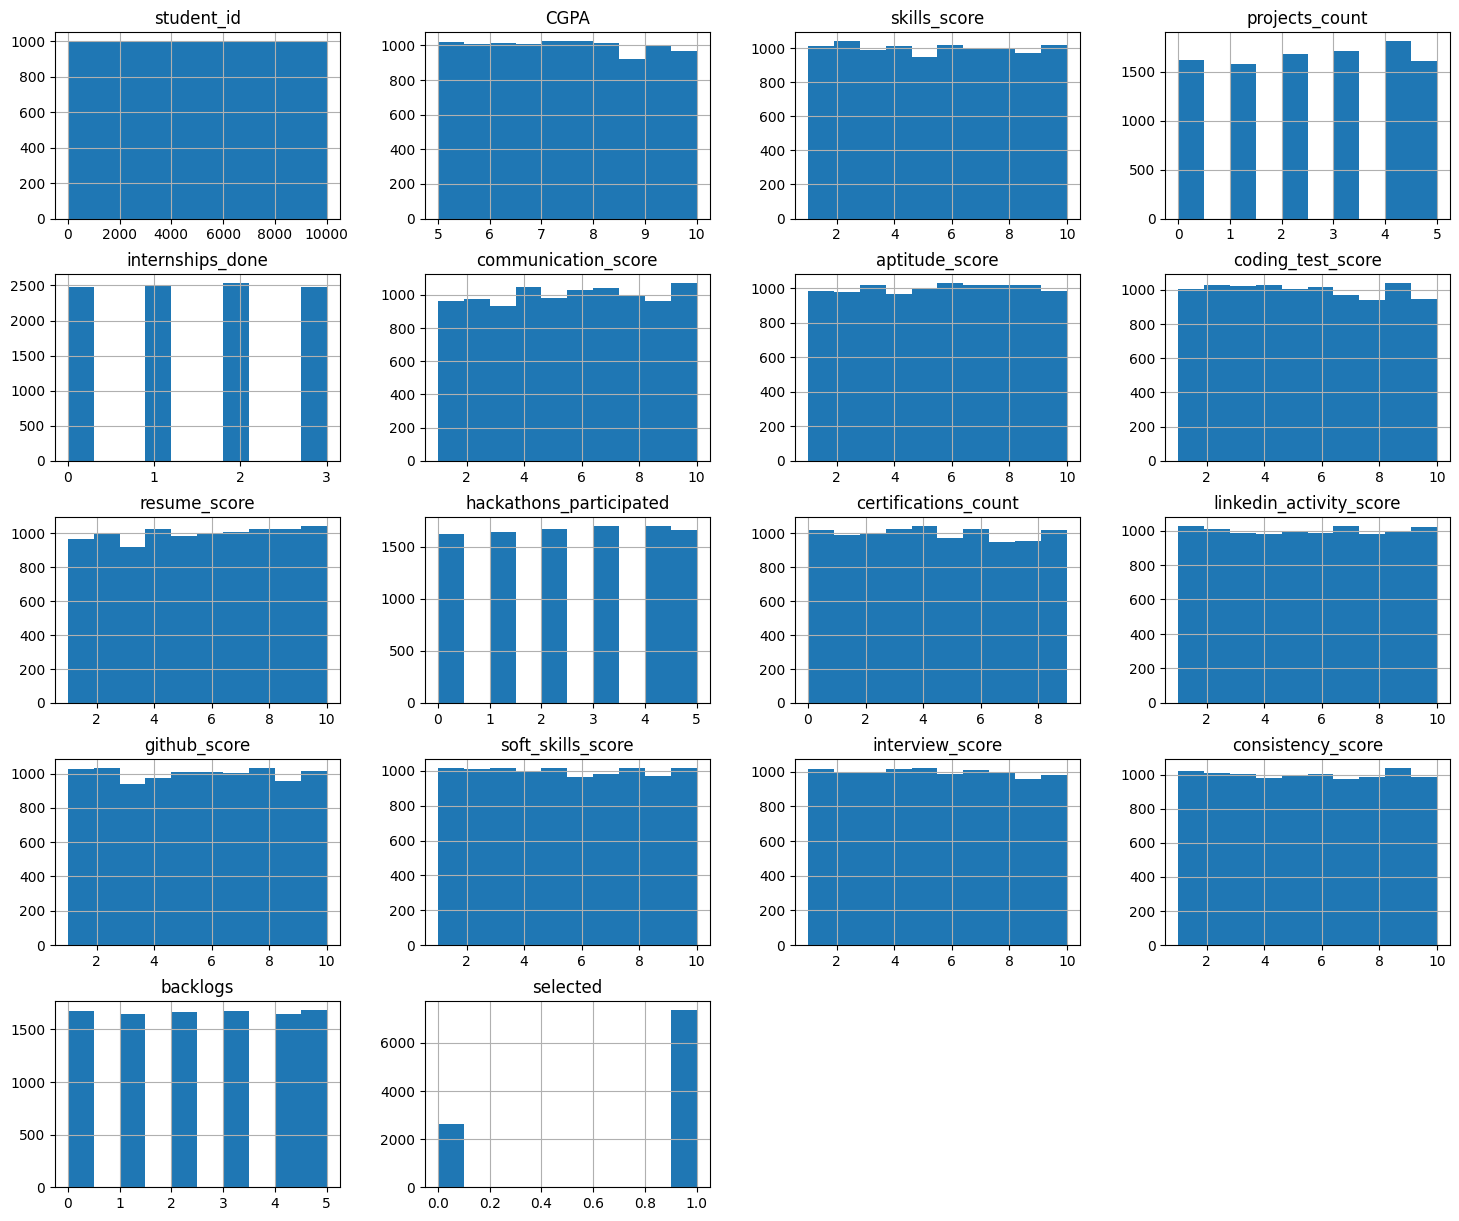

In [105]:
df.hist(figsize=(18,15))
plt.show()

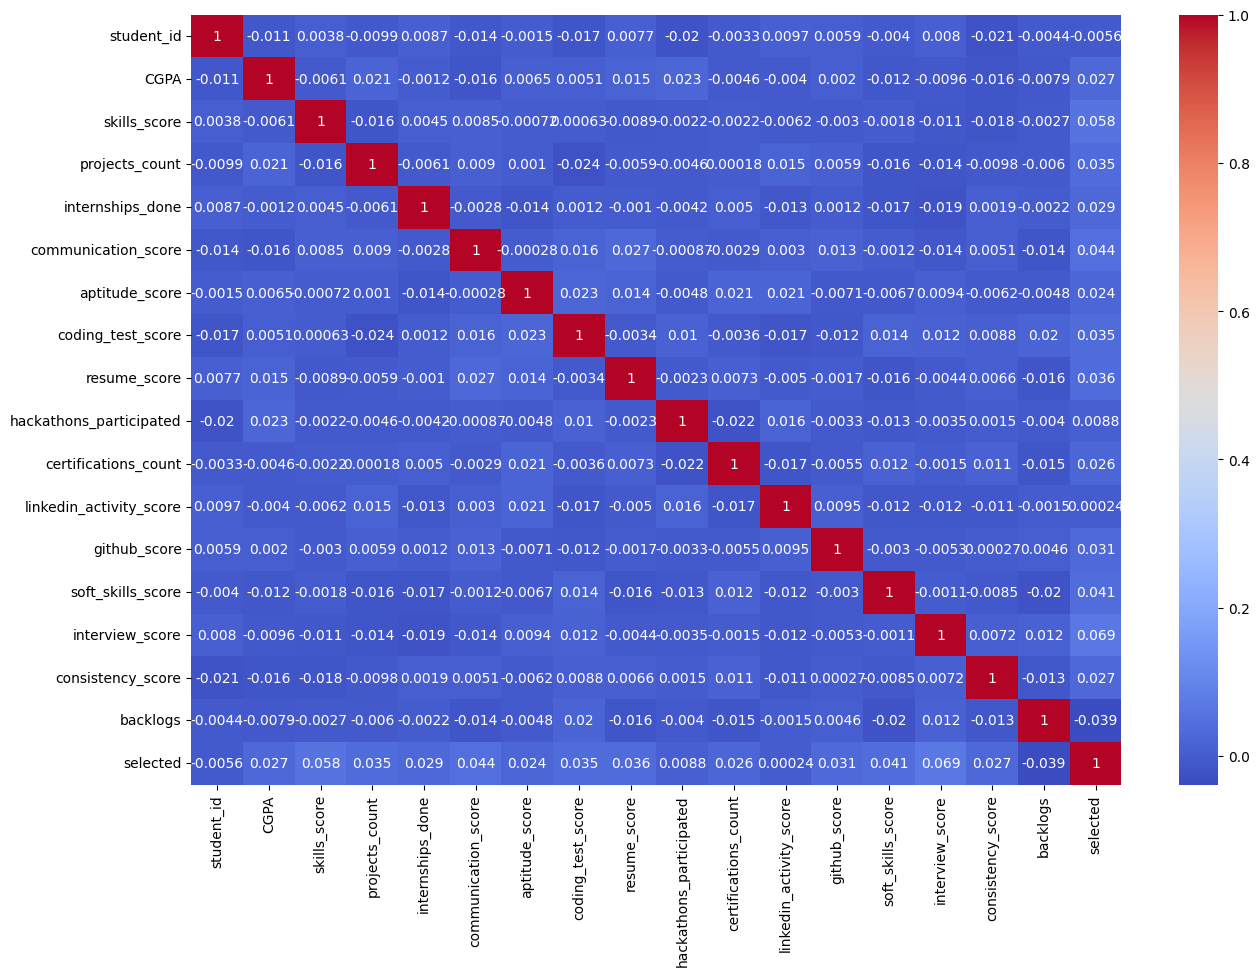

In [106]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

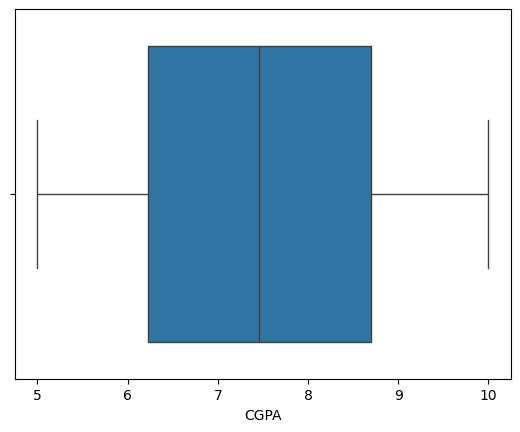

In [107]:
sns.boxplot(x=df["CGPA"])
plt.show()

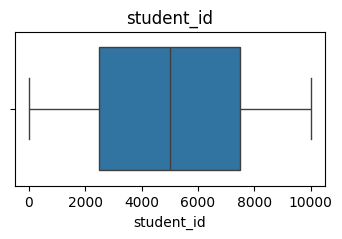

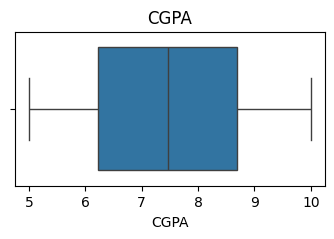

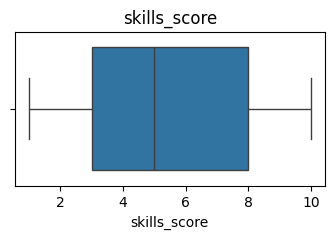

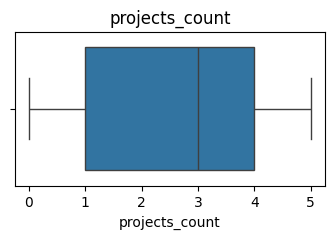

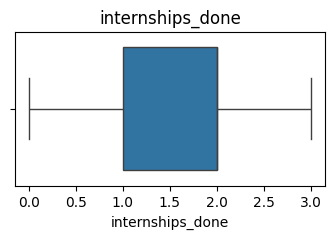

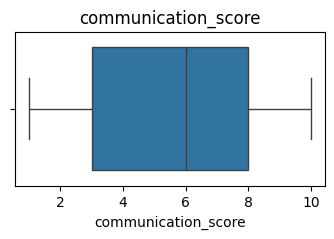

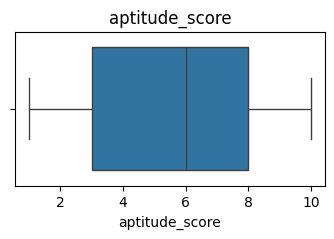

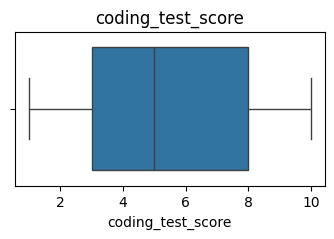

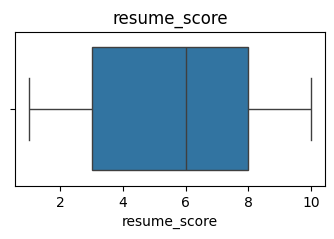

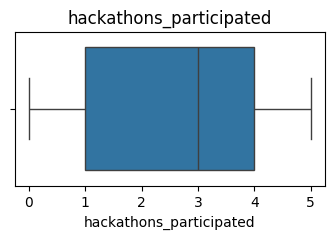

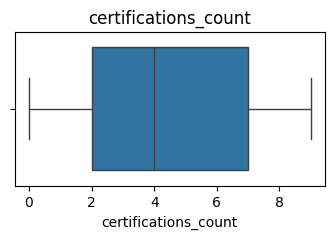

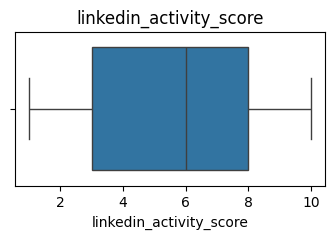

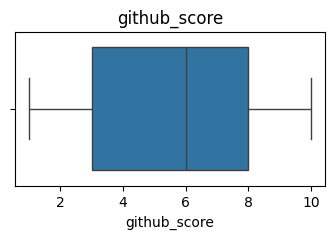

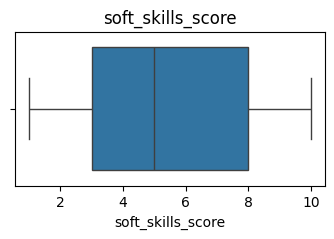

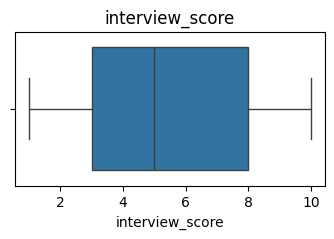

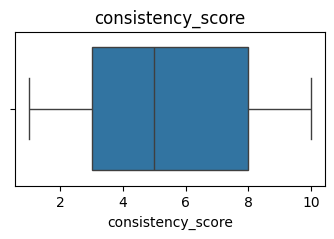

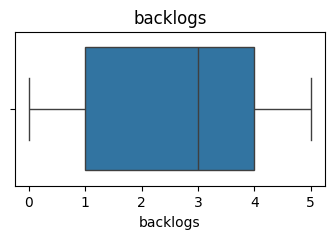

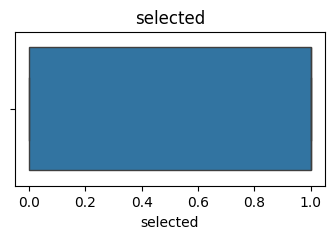

In [108]:
for col in df.select_dtypes(include=['int64','float64']):
    plt.figure(figsize=(4,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

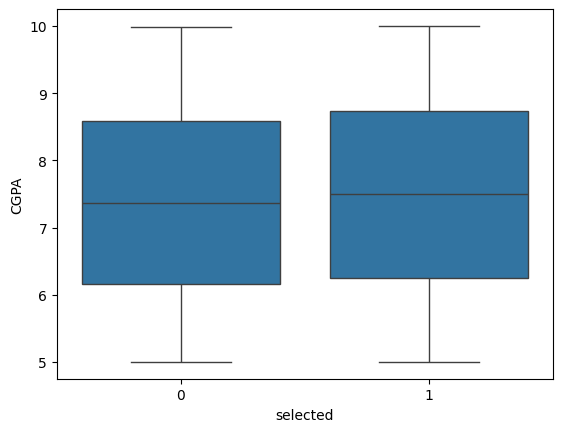

In [109]:
sns.boxplot(x="selected", y="CGPA", data=df)
plt.show()

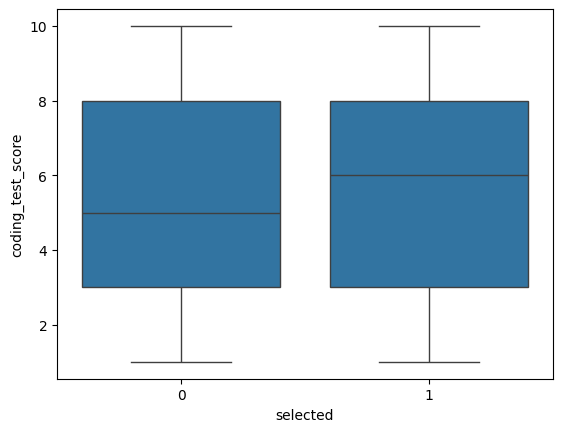

In [110]:
sns.boxplot(x="selected", y="coding_test_score", data=df)
plt.show()

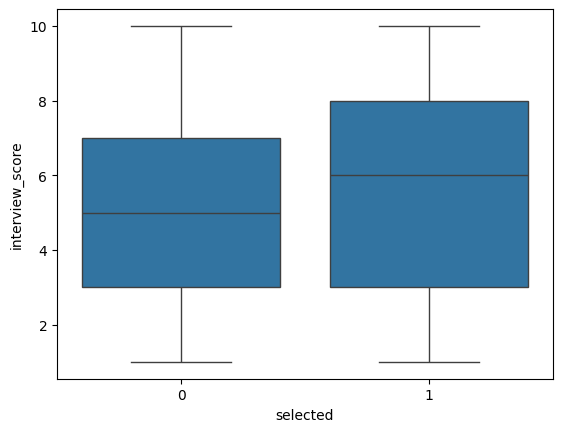

In [111]:
sns.boxplot(x="selected", y="interview_score", data=df)
plt.show()

In [112]:
#remove unnecessary columns
df.drop('student_id', axis=1 , inplace=True)

In [113]:
df.columns

Index(['CGPA', 'skills_score', 'projects_count', 'internships_done',
       'communication_score', 'aptitude_score', 'coding_test_score',
       'resume_score', 'extracurricular', 'college_tier',
       'hackathons_participated', 'certifications_count',
       'linkedin_activity_score', 'github_score', 'soft_skills_score',
       'interview_score', 'consistency_score', 'backlogs',
       'placement_training', 'selected'],
      dtype='object')

In [114]:
#Encoding categorical variables
df["extracurricular"]=df["extracurricular"].map({"No":0 , "Yes":1})
df["placement_training"]=df["placement_training"].map({"No":0 , "Yes":1})
df["college_tier"]=df["college_tier"].map({"Tier 1":1 , "Tier 2":2 , "Tier 3":3})

In [115]:
#check the data types after encoding
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CGPA                     10000 non-null  float64
 1   skills_score             10000 non-null  int64  
 2   projects_count           10000 non-null  int64  
 3   internships_done         10000 non-null  int64  
 4   communication_score      10000 non-null  int64  
 5   aptitude_score           10000 non-null  int64  
 6   coding_test_score        10000 non-null  int64  
 7   resume_score             10000 non-null  int64  
 8   extracurricular          10000 non-null  int64  
 9   college_tier             10000 non-null  int64  
 10  hackathons_participated  10000 non-null  int64  
 11  certifications_count     10000 non-null  int64  
 12  linkedin_activity_score  10000 non-null  int64  
 13  github_score             10000 non-null  int64  
 14  soft_skills_score      

In [116]:
df["selected"].value_counts()

,count
selected,
1,7374
0,2626


In [117]:
#spliting
X = df.drop("selected", axis=1)
y = df["selected"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [118]:
#scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [119]:
print(X_train, X_test)

[[-0.71982144  1.56882762 -0.31956101 ...  1.2170349   1.46029484
   0.67145542]
 [ 0.29401157 -0.85674794  0.2719448  ... -1.54787347  1.46029484
  -1.48930216]
 [ 0.85648057  0.18278444 -1.50257264 ...  0.52580781 -0.87722879
   0.67145542]
 ...
 [-1.35867511  1.56882762 -0.91106683 ... -1.20225992 -0.29284788
   0.67145542]
 [ 0.9606415   0.87580603 -1.50257264 ... -0.85664638 -0.87722879
   0.67145542]
 [-0.01152714  0.18278444  0.2719448  ...  1.2170349   1.46029484
   0.67145542]] [[ 1.07869055  0.87580603 -0.31956101 ... -0.85664638  0.29153302
   0.67145542]
 [ 0.04402535 -0.16372635 -1.50257264 ... -1.20225992  0.29153302
   0.67145542]
 [ 0.20373877 -0.51023714 -0.91106683 ...  0.87142136  0.87591393
   0.67145542]
 ...
 [-1.44200385 -0.85674794  0.2719448  ...  0.52580781 -0.87722879
   0.67145542]
 [-0.3448421   0.52929524 -0.91106683 ...  0.87142136  0.29153302
   0.67145542]
 [-0.66426894  0.18278444 -0.91106683 ... -1.54787347 -0.87722879
   0.67145542]]


In [120]:
# Modeling

In [121]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42 ),
    "KNN": KNeighborsClassifier( ),
    "Decision Tree": DecisionTreeClassifier( random_state=42 ),
    "Random Forest": RandomForestClassifier(  random_state=42),
    "SVM": SVC(  probability=True, random_state=42),
    "Naive Bayes": GaussianNB()
}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)

    y_test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    gap = train_accuracy - test_accuracy
    results.append([
        name,
        f"{train_accuracy*100:.1f}%",
        f"{test_accuracy*100:.1f}%",
        f"{gap*100:.1f}%"
    ])
performance_df = pd.DataFrame(
    results,
    columns=["Model", "Train Accuracy", "Test Accuracy", "Gap"]
)

display(performance_df)

,Model,Train Accuracy,Test Accuracy,Gap
0,Logistic Regression,73.7%,73.7%,0.0%
1,KNN,77.7%,67.8%,9.9%
2,Decision Tree,100.0%,62.2%,37.8%
3,Random Forest,100.0%,73.6%,26.4%
4,SVM,73.7%,73.8%,-0.0%
5,Naive Bayes,73.8%,73.7%,0.1%


In [122]:
# Best_Models , Comparison

In [123]:
best_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB()
}
results = []
for name, model in best_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ])
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]
)
results_df = results_df.sort_values(by="Accuracy", ascending=False)
display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,SVM,0.7375,0.737500,1.000000,0.848921,0.520360
0,Logistic Regression,0.7370,0.737606,0.998644,0.848502,0.602040
2,Naive Bayes,0.7370,0.737845,0.997966,0.848415,0.601489


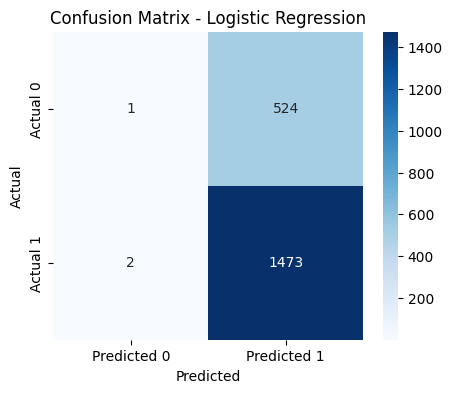

--------------------------------------------------


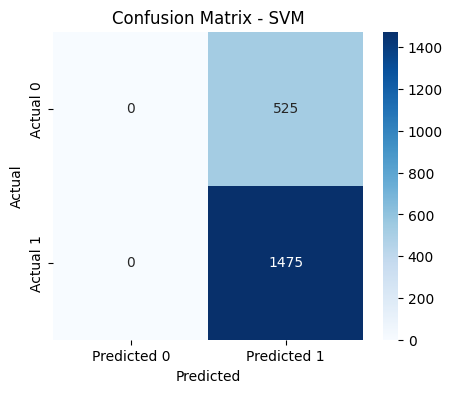

--------------------------------------------------


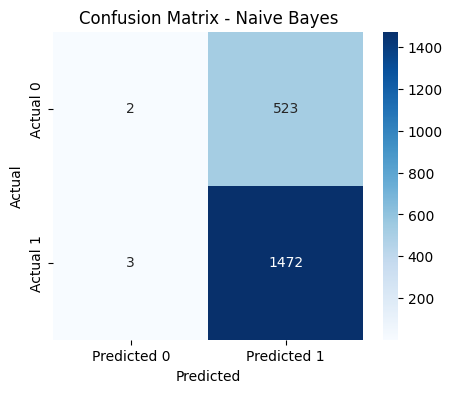

--------------------------------------------------


In [124]:
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Predicted 0', 'Predicted 1'],
        yticklabels=['Actual 0', 'Actual 1']
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    print("-" * 50)

In [125]:
#Data_Imbalanced -> class_weight

In [126]:
best_models = {
    "Logistic Regression": LogisticRegression( class_weight='balanced', max_iter=1000, random_state=42 ),
    "SVM": SVC( probability=True,class_weight='balanced', random_state=42  ),
    "Naive Bayes": GaussianNB()
}
results = []

for name, model in best_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1 Score","ROC AUC"]
)
display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.5710,0.786977,0.573559,0.663529,0.601778
1,SVM,0.5765,0.770224,0.606780,0.678802,0.554095
2,Naive Bayes,0.7370,0.737845,0.997966,0.848415,0.601489


Logistic Regression

 Classification Report:
              precision    recall  f1-score   support

 Refused (0)       0.32      0.56      0.41       525
Accepted (1)       0.79      0.57      0.66      1475

    accuracy                           0.57      2000
   macro avg       0.55      0.57      0.54      2000
weighted avg       0.66      0.57      0.60      2000


 Confusion Matrix Visual:


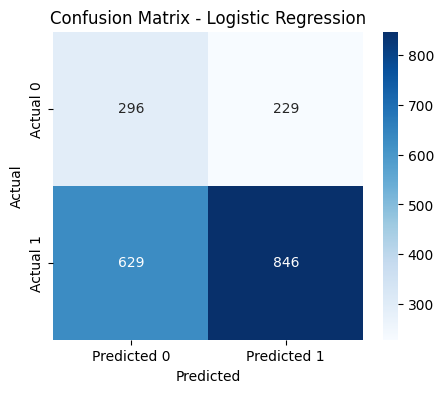




SVM

 Classification Report:
              precision    recall  f1-score   support

 Refused (0)       0.31      0.49      0.38       525
Accepted (1)       0.77      0.61      0.68      1475

    accuracy                           0.58      2000
   macro avg       0.54      0.55      0.53      2000
weighted avg       0.65      0.58      0.60      2000


 Confusion Matrix Visual:


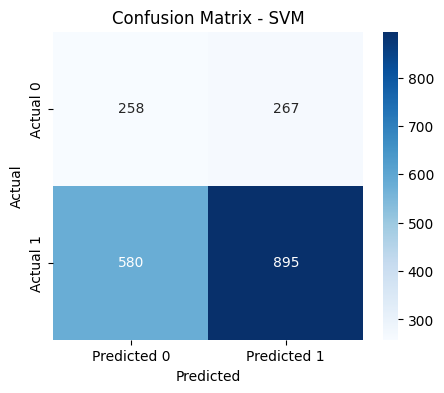




Naive Bayes

 Classification Report:
              precision    recall  f1-score   support

 Refused (0)       0.40      0.00      0.01       525
Accepted (1)       0.74      1.00      0.85      1475

    accuracy                           0.74      2000
   macro avg       0.57      0.50      0.43      2000
weighted avg       0.65      0.74      0.63      2000


 Confusion Matrix Visual:


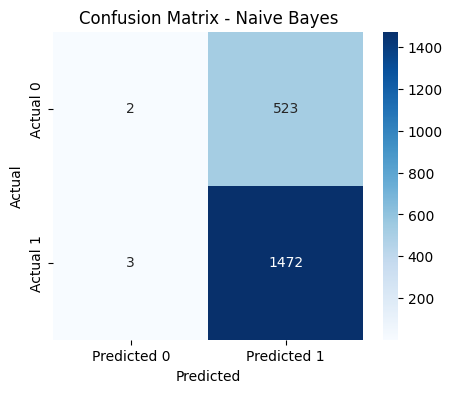

In [127]:
best_models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, class_weight='balanced', random_state=42),
    "Naive Bayes": GaussianNB()
}
for name, model in best_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    print("=" * 60)
    print(f"{name}")
    print("=" * 60)

    print("\n Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Refused (0)', 'Accepted (1)']))
    print("\n Confusion Matrix Visual:")

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Predicted 0', 'Predicted 1'],
        yticklabels=['Actual 0', 'Actual 1']
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    print("\n\n")

In [128]:
# Hyperparameter Tuning

In [129]:
logistic_model = LogisticRegression(max_iter=1000,random_state=42)

param_grid = { 'C': [0.01, 0.1, 1, 10, 100],
              'solver': ['liblinear', 'lbfgs'],
               'class_weight': ['balanced']
               }
grid_search = GridSearchCV(
    estimator=logistic_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Score:")
print(grid_search.best_score_)

Best Parameters:
{'C': 1, 'class_weight': 'balanced', 'solver': 'liblinear'}

Best Cross-Validation Score:
0.528660434450619


In [130]:
# after tuning
best_model = grid_search.best_estimator_
y_pred_after = best_model.predict(X_test)
y_prob_after = best_model.predict_proba(X_test)[:, 1]

print("After Tuning:")
print("Accuracy:", accuracy_score(y_test, y_pred_after))
print("Precision:", precision_score(y_test, y_pred_after))
print("Recall:", recall_score(y_test, y_pred_after))
print("F1 Score:", f1_score(y_test, y_pred_after))
print("ROC AUC:", roc_auc_score(y_test, y_prob_after))

After Tuning:
Accuracy: 0.571
Precision: 0.7869767441860465
Recall: 0.5735593220338983
F1 Score: 0.6635294117647059
ROC AUC: 0.6017833736884584


In [131]:
coefficients = pd.DataFrame({"Feature": X.columns,"Coefficient": best_model.coef_[0]})
coefficients["Importance"] = coefficients["Coefficient"].abs()
print(coefficients.sort_values("Importance", ascending=False))

                    Feature  Coefficient  Importance
15          interview_score     0.171819    0.171819
1              skills_score     0.138055    0.138055
4       communication_score     0.111558    0.111558
6         coding_test_score     0.089031    0.089031
2            projects_count     0.088182    0.088182
14        soft_skills_score     0.085062    0.085062
17                 backlogs    -0.083857    0.083857
3          internships_done     0.073387    0.073387
7              resume_score     0.069881    0.069881
11     certifications_count     0.068691    0.068691
8           extracurricular     0.060311    0.060311
16        consistency_score     0.057864    0.057864
18       placement_training     0.056794    0.056794
13             github_score     0.049930    0.049930
0                      CGPA     0.048122    0.048122
9              college_tier    -0.043580    0.043580
5            aptitude_score     0.034891    0.034891
10  hackathons_participated     0.025346    0.